## UNPAZ LGTI - SISTEMAS INTELIGENTES 2025
### TP INDIVIDUAL
- ESTUDIANTE: Santiago Cuevas
- EXPERIMENTO NUM: 001

## Librerías

In [193]:
import os
import numpy as np
np.set_printoptions(suppress=True)

import requests

from PIL import Image
import random
import matplotlib.image as mpimg

import matplotlib.pyplot as plt
import seaborn as sns
# Setear globalmente los estilos de matplotlib
sns.set_theme("notebook")

In [194]:
from sklearn.metrics import confusion_matrix

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Flatten, Dense, Dropout, Rescaling, BatchNormalization,RandomFlip, RandomRotation, RandomZoom, RandomContrast

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [195]:
# Función auxiliar para plotear la matriz de confusión
def plot_matriz_confusion(matriz_de_confusion,
                          labels = False,
                          titulo = "Matriz de confusión",
                          subtitulo = ""):
    fig, ax = plt.subplots()
    
    ax = sns.heatmap(matriz_de_confusion,
                     annot=True,
                     cbar=False,
                     fmt ='g')
    
    if(labels != False):
        ax.set_xticklabels(labels, rotation=45)
        ax.set_yticklabels(labels, rotation=0)
    
    fig.suptitle(titulo)
    ax.set_title(subtitulo)

    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta real")

    plt.tight_layout()

    plt.show()

## Constantes

In [196]:
# Algunas constantes que van a ser utilizadas en varios lugares del código.

# Nombre del modelo
MODELO_NOMBRE = "003-Cuevas_Pets"

# Hiperparámetros
EPOCHS = 50
BATCH_SIZE = 16
LEARNING_RATE = 0.002

# Carpeta con datos de entrenamiento
DATASET_TRAIN_DIR = "recursos/pets_2/train"

# Carpeta con con datos de prueba
DATASET_TEST_DIR = "recursos/pets_2/test"

# Tamaño al cual se van a redimensionar las imágenes para procesarlas
IMG_WIDTH = 128
IMG_HEIGHT = 128

## Cargando el dataset de entrenamiento

In [197]:
# Generar un Dataset con el directorio de archivos de train
# Función image_dataset_from_directory
# Lee datos del disco en batches, evitando colapsar la RAM
# si se cargaran todas las imágenes en memoria.
dataset_train = tf.keras.preprocessing.image_dataset_from_directory(
    # Directorio
    DATASET_TRAIN_DIR,
    
    # Etiquetas inferidas desde los nombres de directorios
    labels='inferred',
    
    # Clasificación categórica
    label_mode='categorical',
    
    batch_size=BATCH_SIZE,
    image_size=(IMG_WIDTH, IMG_HEIGHT),

    # Es conveniente shuffle=True porque entrenar con ejemplos de múltiples clases sin mezclarlos
    # podría derivar en que el modelo no aprenda ya que se puede quedar en un mínimo local.
    # Para calcular las métricas sobre el final se importará de nuevo con shuffle=False
    shuffle=True
)

print("Clases dataset entrenamiento: ", dataset_train.class_names)

# Agrego variable para consumir por las dudas jeje
CANTIDAD_CLASES = len(dataset_train.class_names)

Found 875 files belonging to 5 classes.
Clases dataset entrenamiento:  ['boxer', 'bulldog', 'chihuahua', 'pitbull', 'setter']


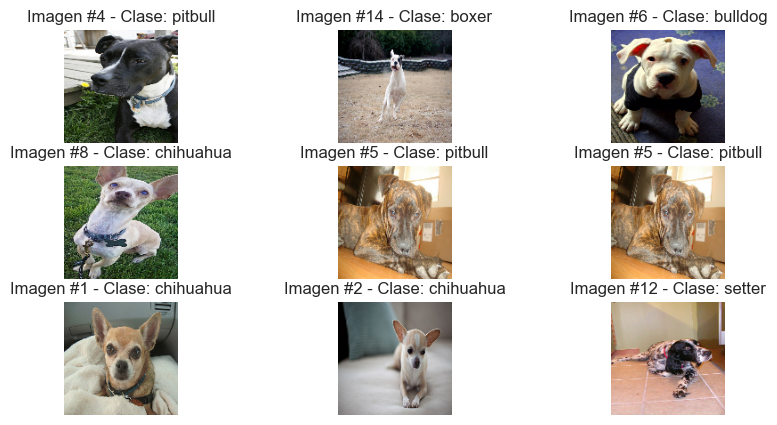

In [198]:
# Veamos algunas imágenes de entrenamiento
plt.figure(figsize=(10, 5))
for images, labels in dataset_train.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        img_indice = random.randint(0, len(images)-1)
        img_clase_categoria = np.argmax(labels[img_indice])
        img_clase_nombre = dataset_train.class_names[img_clase_categoria]
        plt.imshow(images[img_indice].numpy().astype("uint8"))
        titulo_imagen = f"Imagen #{img_indice} - Clase: {img_clase_nombre}"
        plt.title(titulo_imagen)
        plt.axis("off")

## Creación del modelo

In [199]:
# Modelo
modelo = Sequential([
    Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    Rescaling(1./255),

    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.05),
    #  Conv 1
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu',padding='same',use_bias=False),
    BatchNormalization(momentum=0.9),
    MaxPooling2D(pool_size=(2,2)),
    
    #  Conv 2
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    
    #  Conv 3
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    # 2 capas dense de relu
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(5, activation='softmax')
])

In [200]:
# Compilar el modelo
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy'])

In [201]:
# Resumen del modelo
modelo.summary(line_length=80)

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_23 (Rescaling)          │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ random_flip_18 (RandomFlip)       │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ random_rotation_18                │ (None, 128, 128, 3)      │             0 │
│ (RandomRotation)                  │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ random_zoom_17 (RandomZoom)       │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)                │ (None, 128, 128, 32)     │           864 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_33            │ (None, 128, 128, 32)     │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D)   │ (None, 64, 64, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)                │ (None, 64, 64, 64)       │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_34            │ (None, 64, 64, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_68 (MaxPooling2D)   │ (None, 32, 32, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)                │ (None, 32, 32, 64)       │        36,928 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_35            │ (None, 32, 32, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D)   │ (None, 16, 16, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ flatten_23 (Flatten)              │ (None, 16384)            │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_71 (Dense)                  │ (None, 128)              │     2,097,280 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_72 (Dense)                  │ (None, 64)               │         8,256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_73 (Dense)                  │ (None, 5)                │           325 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 2,162,789 (8.25 MB)

 Trainable params: 2,162,469 (8.25 MB)

 Non-trainable params: 320 (1.25 KB)

## Entrenamiento del modelo

In [202]:
# Entrenamos el modelo
entrenamiento_info = modelo.fit(
    dataset_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.2343 - loss: 3.8135
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.2286 - loss: 2.1704
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.2411 - loss: 1.6050
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.3029 - loss: 1.5428
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.3154 - loss: 1.5092
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.3177 - loss: 1.4920
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.3497 - loss: 1.4949
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.3669 - loss: 1.4306
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.3680 - loss: 1.4069
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.3771 - loss: 1.4065
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.3771 - loss: 1.4087
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy:

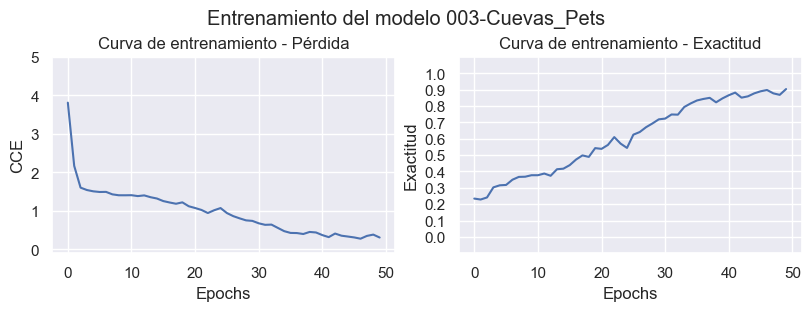

In [203]:
# Ploteos del entrenamiento del modelo
fig, axs = plt.subplot_mosaic([
    ['perdida', 'exactitud']
],
    layout='constrained',
    figsize=(8, 3)
)

axs['perdida'].set_title('Curva de entrenamiento - Pérdida')
axs['perdida'].plot(entrenamiento_info.history['loss'])
axs['perdida'].grid(True)
axs['perdida'].set_ylim(-0.1, 5)
axs['perdida'].set_xlabel("Epochs")
axs['perdida'].set_ylabel("CCE")

axs['exactitud'].set_title('Curva de entrenamiento - Exactitud')
axs['exactitud'].plot(entrenamiento_info.history['accuracy'])
axs['exactitud'].grid(True)
axs['exactitud'].set_ylim(-0.1, 1.1)
axs['exactitud'].set_yticks(np.arange(0, 1.05, 0.10))
axs['exactitud'].set_xlabel("Epochs")
axs['exactitud'].set_ylabel("Exactitud")

plt.suptitle(f"Entrenamiento del modelo {MODELO_NOMBRE}")
plt.show()

## Métricas conj. de entrenamiento

In [212]:
# Volver a armar el dataset de train con shuffle = False
# Para poder calcular ok las métricas con este conjunto de datos.
dataset_train = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=(IMG_WIDTH, IMG_HEIGHT),
    shuffle=False
)

Found 875 files belonging to 5 classes.


In [213]:
# image_dataset_from_directory trae datos en batches con y codificada categórica/onehot.

# Iterar para obtener todas las y del conjunto correspondiente
y_train = tf.concat([y for x, y in dataset_train], axis=0)

# Obtener la clase como entero (índice con mayor valor del elemento)
# para luego comparar con las predicciones.
y_train_clase = np.argmax(y_train, axis=1)

# Predicciones
y_train_pred_proba = modelo.predict(dataset_train)

# Obtener la clase como entero (índice con mayor valor del elemento)
# para luego comparar con las predicciones.
y_train_pred_clase = np.argmax(y_train_pred_proba, axis=1)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [214]:
perdida_train, exactitud_train = modelo.evaluate(dataset_train)

 1/55 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 1.0000 - loss: 0.0500

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9257 - loss: 0.2013


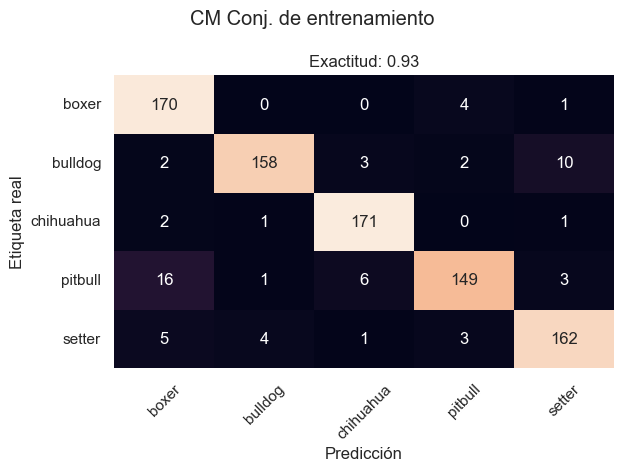

In [215]:
plot_matriz_confusion(
    confusion_matrix(y_train_clase,y_train_pred_clase),
    labels=dataset_train.class_names,
    titulo='CM Conj. de entrenamiento',
    subtitulo=f"Exactitud: {np.round(exactitud_train, 2)}")

## Métricas conjunto de prueba

In [216]:
dataset_test = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=(IMG_WIDTH, IMG_HEIGHT),
    shuffle=False
)

Found 125 files belonging to 5 classes.


In [220]:
# image_dataset_from_directory trae datos en batches con y codificada categórica/onehot.

# Iterar para obtener todas las y del conjunto correspondiente
y_test = tf.concat([y for x, y in dataset_test], axis=0)

# Obtener la clase como entero (índice con mayor valor del elemento)
# para luego comparar con las predicciones.
y_test_clase = np.argmax(y_test, axis=1)

# Predicciones
y_test_pred_proba = modelo.predict(dataset_test)

# Obtener la clase como entero (índice con mayor valor del elemento)
# para luego comparar con las predicciones.
y_test_pred_clase = np.argmax(y_test_pred_proba, axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [223]:
perdida_test, exactitud_test = modelo.evaluate(dataset_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4400 - loss: 2.7530


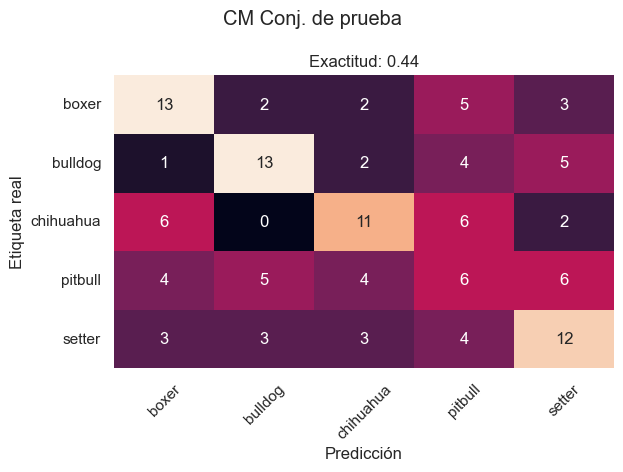

In [222]:
plot_matriz_confusion(
    confusion_matrix(y_test_clase, y_test_pred_clase),
    labels=dataset_test.class_names,
    titulo='CM Conj. de prueba',
    subtitulo=f"Exactitud: {np.round(exactitud_test, 2)}")